# Exponential Smoothing — Simple, Double and Triple

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/diogoalvesderesende/time-series-forecasting-python/blob/main/Time%20Series%20Analysis/Exponential%20Smoothing%20and%20Holt%20Winters/Exponential%20Smoothing.ipynb)

The remade walkthrough. Builds the three exponential smoothing models in order and compares them on
the same data, then repeats the exercise on a daily series.

| | |
|---|---|
| **Course section** | Exponential Smoothing & Holt-Winters |
| **Data** | `weekly_customer_complaints.csv`, `bitcoin_price.csv` |
| **Runs on** | CPU |

## Roadmap

1. Setup and data loading
2. Visualise the series
3. Split into training and test
4. **Simple** exponential smoothing — level only
5. **Double** exponential smoothing (Holt) — level and trend
6. **Triple** exponential smoothing (Holt-Winters) — level, trend and season
7. Compare the three with MAE, RMSE and MAPE
8. Refit on all the data and forecast forward
9. Repeat on a daily series

## The one idea behind all three

Recent observations tell you more about tomorrow than old ones do. Exponential smoothing puts a number
on that: each model keeps a weighted average of the past where the weights decay as you go back in
time, and `alpha` controls how fast they decay.

- **Simple** smooths the level. Flat forecasts.
- **Double** adds a trend term, so forecasts can slope.
- **Triple (Holt-Winters)** adds a seasonal term, so forecasts can repeat a cycle.

Additive seasonality means the swing is a fixed size. Multiplicative means the swing grows with the
level. Plot the series first: if the peaks get taller as the series rises, you want multiplicative.

---

Part of **[Master Time Series Analysis and Forecasting with Python](https://www.udemy.com/course/forecasting-python/?referralCode=63045C9CC807EB1EBD9A)** · [All notebooks](https://github.com/diogoalvesderesende/time-series-forecasting-python)

# Setup

https://gamma.app/docs/Time-Series-Analysis-dl7lp24qu0frv6e

In [ ]:
# --- Setup -------------------------------------------------------------------
# Works three ways, in this order:
#   1. Google Drive, if you copied the course folder there (what the videos show)
#   2. The notebook's own folder, if you cloned the repository
#   3. Downloading this section's data from GitHub, if neither of the above
import os
import urllib.parse
import urllib.request

DRIVE_FOLDER = "/content/drive/MyDrive/Python - Time Series Forecasting/Time Series Analysis/Exponential Smoothing and Holt Winters"
REPO_FOLDER = "Time Series Analysis/Exponential Smoothing and Holt Winters"
DATA_FILES = ["bitcoin_price.csv", "weekly_customer_complaints.csv"]
RAW = "https://raw.githubusercontent.com/diogoalvesderesende/time-series-forecasting-python/main/"

try:
    from google.colab import drive
    drive.mount("/content/drive")
    if os.path.isdir(DRIVE_FOLDER):
        os.chdir(DRIVE_FOLDER)
except ImportError:
    pass  # not running on Colab - stay where we are

# Fetch anything that is not already next to the notebook.
for name in DATA_FILES:
    if not os.path.exists(name):
        print(f"Downloading {name} ...")
        urllib.request.urlretrieve(RAW + urllib.parse.quote(REPO_FOLDER + "/" + name), name)

print("Working directory:", os.getcwd())

In [39]:
# Importing essential libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import month_plot, quarter_plot, plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

In [5]:
# Read weekly customer complaints, with "week" as the datetime index
# Expect a CSV with columns: [week, complaints]
df = pd.read_csv("weekly_customer_complaints.csv", index_col = "week", parse_dates = True)
df.head()

,complaints,discount_rate,small_commercial_event,medium_commercial_event,big_commercial_event
week,,,,,
2018-01-01,"1,750",37.26%,1,0,0
2018-01-08,"1,701",35.38%,0,0,0
2018-01-15,"1,711",36.22%,1,0,0
2018-01-22,"1,443",38.33%,1,0,0
2018-01-29,"1,397",36.34%,0,0,0


In [6]:
# rename "complaints" to "y"
df = df.rename(columns = {"complaints" : "y"})
df.head(1)

,y,discount_rate,small_commercial_event,medium_commercial_event,big_commercial_event
week,,,,,
2018-01-01,"1,750",37.26%,1,0,0


In [7]:
#Look into the df info
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 261 entries, 2018-01-01 to 2022-12-26
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   y                        261 non-null    object
 1   discount_rate            261 non-null    object
 2   small_commercial_event   261 non-null    int64 
 3   medium_commercial_event  261 non-null    int64 
 4   big_commercial_event     261 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 12.2+ KB


In [8]:
# Remove the commas from "y"
df["y"] = df["y"].str.replace(",", "").astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 261 entries, 2018-01-01 to 2022-12-26
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   y                        261 non-null    int64 
 1   discount_rate            261 non-null    object
 2   small_commercial_event   261 non-null    int64 
 3   medium_commercial_event  261 non-null    int64 
 4   big_commercial_event     261 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 12.2+ KB


# Data Visualization

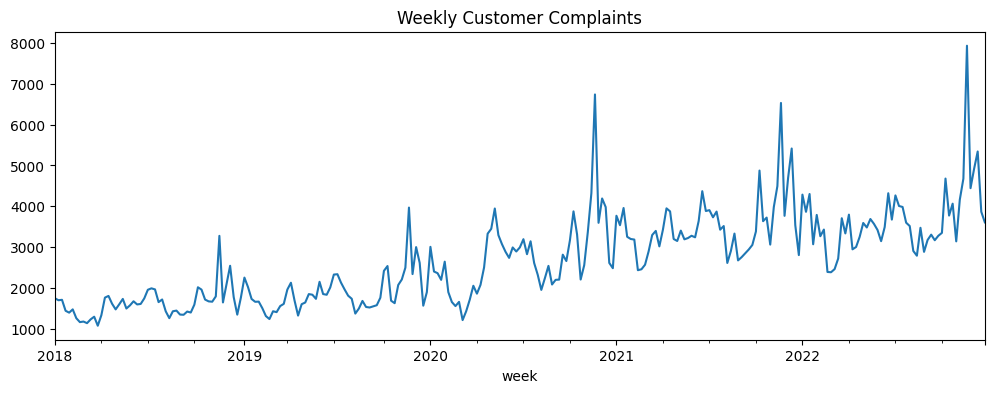

In [9]:
# Simple plot
df["y"].plot(title = "Weekly Customer Complaints", figsize=(12,4))
plt.show()

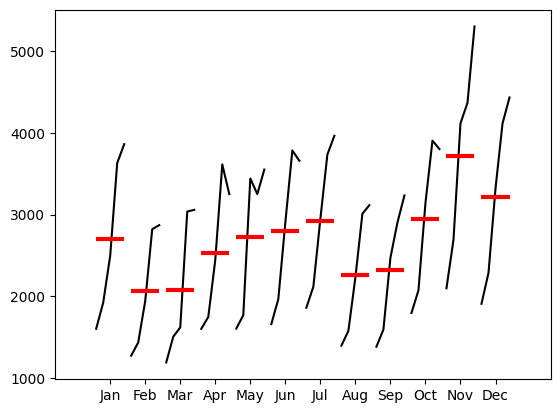

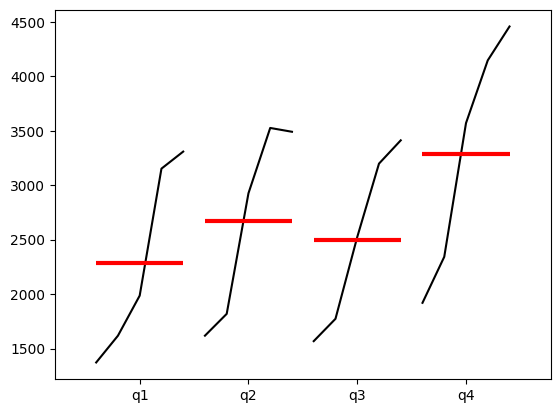

In [10]:
# Plot the Month plot and Quarter Plot
month_plot(df["y"].resample("ME").mean())
quarter_plot(df["y"].resample("QE").mean())
plt.show()

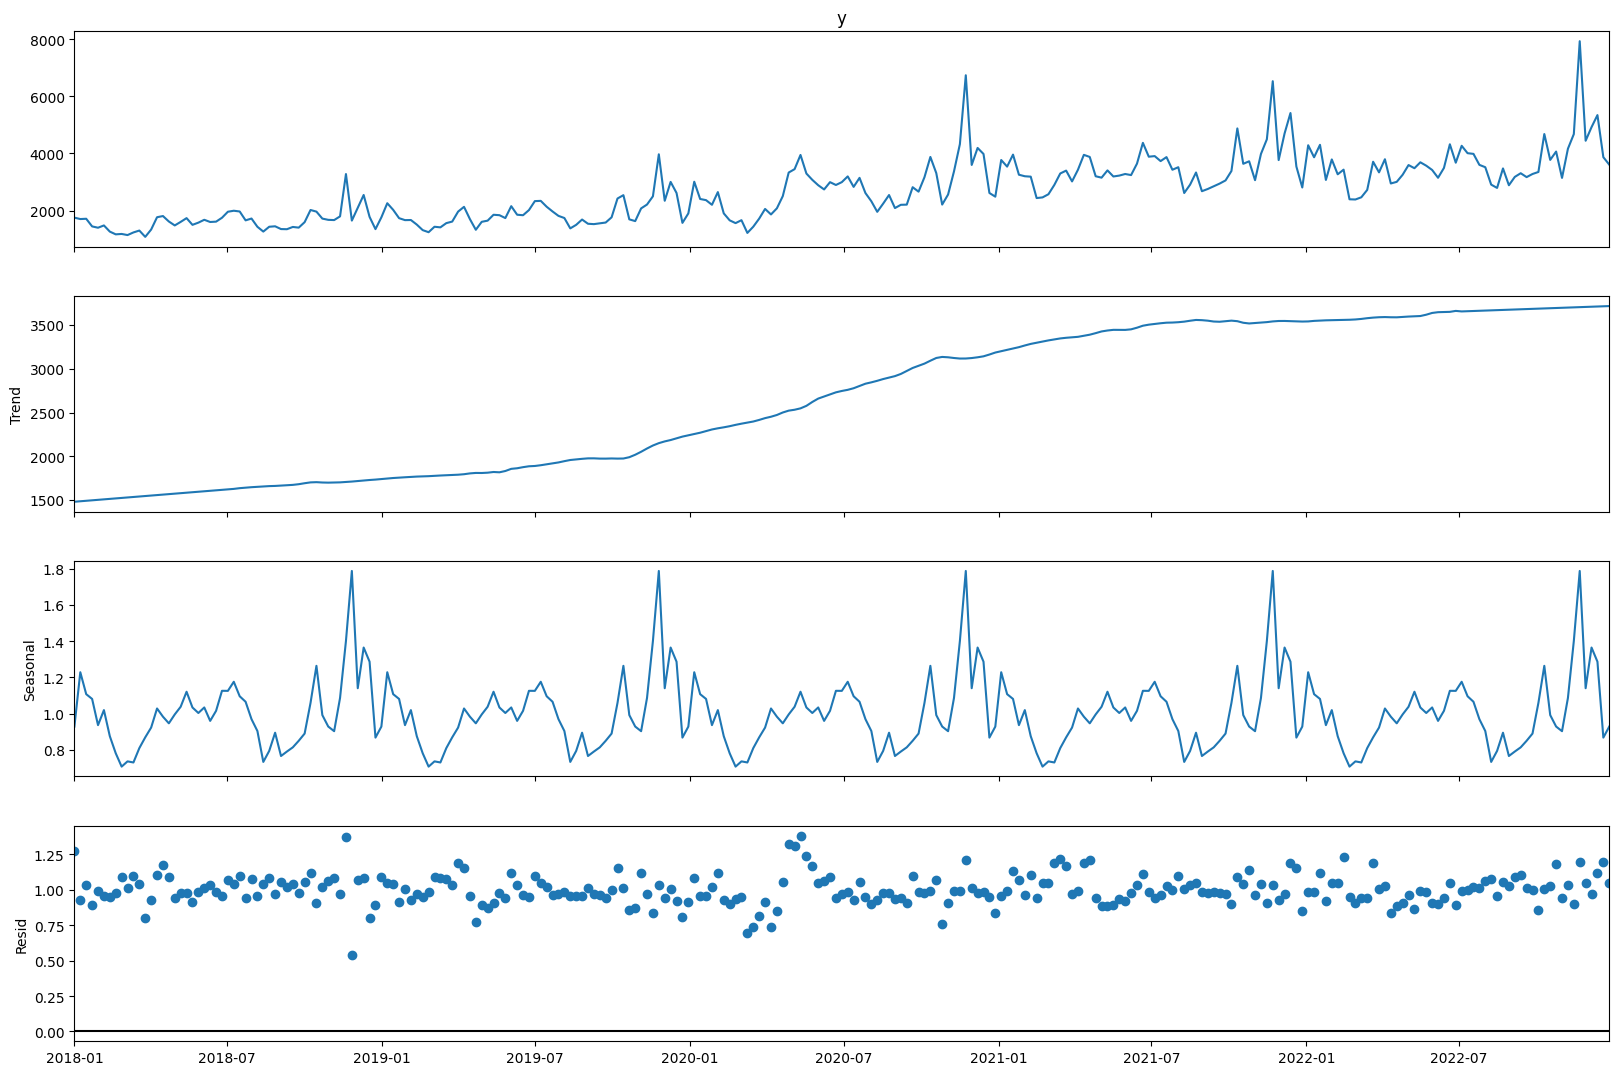

In [11]:
# Perform the seasonal Decomposition
decompose = seasonal_decompose(
    df["y"],
    model = "multiplicative",
    period = 52,
    extrapolate_trend = True)

fig = decompose.plot()
fig.set_size_inches(18,12)
plt.show()

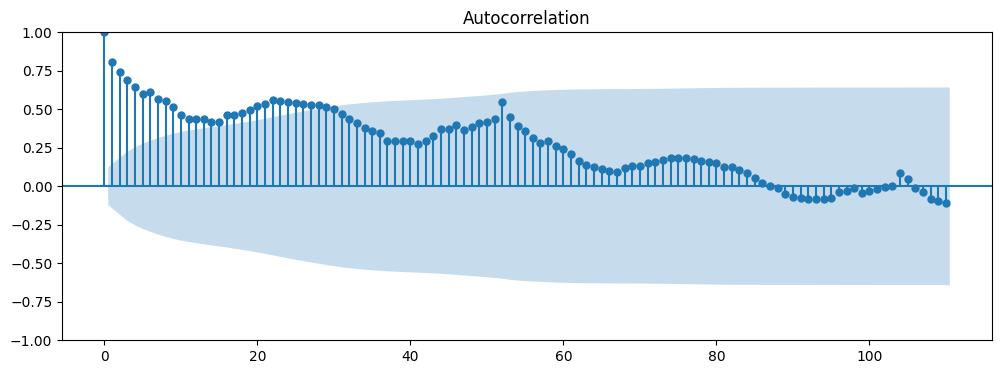

In [12]:
# Plot the ACF
fig, ax = plt.subplots(figsize=(12,4))
plot_acf(df["y"], lags = 110, ax = ax)
plt.show()

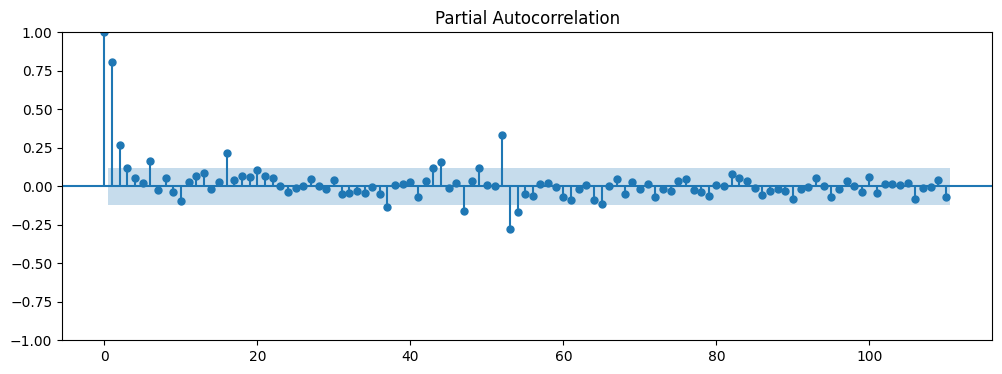

In [13]:
# Plot the PACF
fig, ax = plt.subplots(figsize=(12,4))
plot_pacf(df["y"], lags = 110, ax = ax)
plt.show()

# Training and Test set

In [14]:
# Set the Frequency of the data
df = df.asfreq("W-Mon")
df.index

DatetimeIndex(['2018-01-01', '2018-01-08', '2018-01-15', '2018-01-22',
               '2018-01-29', '2018-02-05', '2018-02-12', '2018-02-19',
               '2018-02-26', '2018-03-05',
               ...
               '2022-10-24', '2022-10-31', '2022-11-07', '2022-11-14',
               '2022-11-21', '2022-11-28', '2022-12-05', '2022-12-12',
               '2022-12-19', '2022-12-26'],
              dtype='datetime64[ns]', name='week', length=261, freq='W-MON')

In [15]:
#Set the training and test
periods = 16 #
train = df.iloc[:-periods, 0]
test = df.iloc[-periods:, 0]

# Simple Exponential Smoothing

In [19]:
# Build the simple exponential smoothing model
ses_model = SimpleExpSmoothing(train).fit()
print(ses_model.summary())

                       SimpleExpSmoothing Model Results                       
Dep. Variable:                      y   No. Observations:                  245
Model:             SimpleExpSmoothing   SSE                       74312308.578
Optimized:                       True   AIC                           3096.520
Trend:                           None   BIC                           3103.522
Seasonal:                        None   AICC                          3096.686
Seasonal Periods:                None   Date:                 Wed, 15 Jul 2026
Box-Cox:                        False   Time:                         10:40:53
Box-Cox Coeff.:                  None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.5101047                alpha                 True
initial_level              1750.0000                

In [20]:
# Predictions
ses_predictions = ses_model.forecast(periods)
ses_predictions

,0
2022-09-12,3122.74724
2022-09-19,3122.74724
2022-09-26,3122.74724
2022-10-03,3122.74724
2022-10-10,3122.74724
2022-10-17,3122.74724
2022-10-24,3122.74724
2022-10-31,3122.74724
2022-11-07,3122.74724
2022-11-14,3122.74724


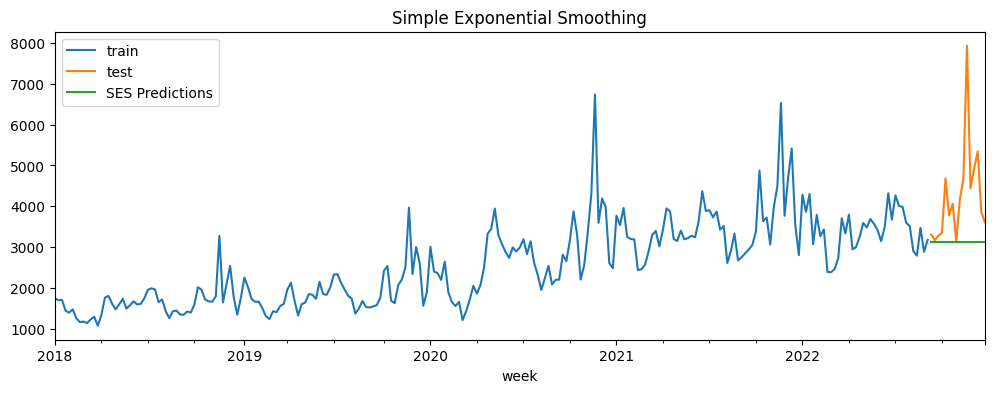

In [23]:
# Plot the train, test and predictions
train.plot(
    title = "Simple Exponential Smoothing",
    figsize=(12,4),
    legend = True,
    label = "train")
test.plot(
    legend = True,
    label = "test"
)
ses_predictions.plot(
    legend = True,
    label = "SES Predictions"
)
plt.show()

# Double Exponential Smoothing

In [32]:
 # Build the double exponential smoothing
des_model = ExponentialSmoothing(
      train,
      trend = "mul",
      seasonal = None,
    #  damped_trend = True,
      seasonal_periods = 52).fit()
print(des_model.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:                        y   No. Observations:                  245
Model:             ExponentialSmoothing   SSE                       74245298.204
Optimized:                         True   AIC                           3100.299
Trend:                   Multiplicative   BIC                           3114.304
Seasonal:                          None   AICC                          3100.652
Seasonal Periods:                  None   Date:                 Wed, 15 Jul 2026
Box-Cox:                          False   Time:                         12:27:38
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.5153211                alpha                 True
smoothing_trend             0.0000

In [33]:
# Predict with the DES model
des_predictions = des_model.forecast(periods)
des_predictions

,0
2022-09-12,3100.209218
2022-09-19,3088.889324
2022-09-26,3077.610762
2022-10-03,3066.373383
2022-10-10,3055.177035
2022-10-17,3044.021568
2022-10-24,3032.906834
2022-10-31,3021.832683
2022-11-07,3010.798968
2022-11-14,2999.805540


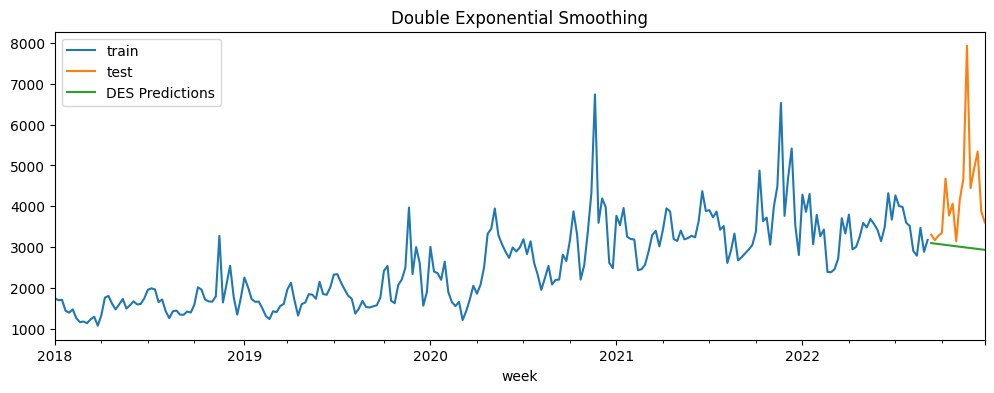

In [34]:
# Plot the Train, Test and Predictions
train.plot(
    title = "Double Exponential Smoothing",
    figsize=(12,4),
    legend = True,
    label = "train")
test.plot(
    legend = True,
    label = "test"
)
des_predictions.plot(
    legend = True,
    label = "DES Predictions"
)
plt.show()

# Triple Exponential Smoothing

In [35]:
# Build the Holt-Winters model
hw_model = ExponentialSmoothing(
      train,
      trend = "mul",
      seasonal = "mul",
      seasonal_periods = 52).fit()
print(hw_model.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:                        y   No. Observations:                  245
Model:             ExponentialSmoothing   SSE                       21507977.013
Optimized:                         True   AIC                           2900.756
Trend:                   Multiplicative   BIC                           3096.826
Seasonal:                Multiplicative   AICC                          2937.551
Seasonal Periods:                    52   Date:                 Wed, 15 Jul 2026
Box-Cox:                          False   Time:                         12:45:48
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.2547449                alpha                 True
smoothing_trend          

In [ ]:
# Predict with the Holt-Winters model
hw_predictions = hw_model.forecast(periods)
hw_predictions

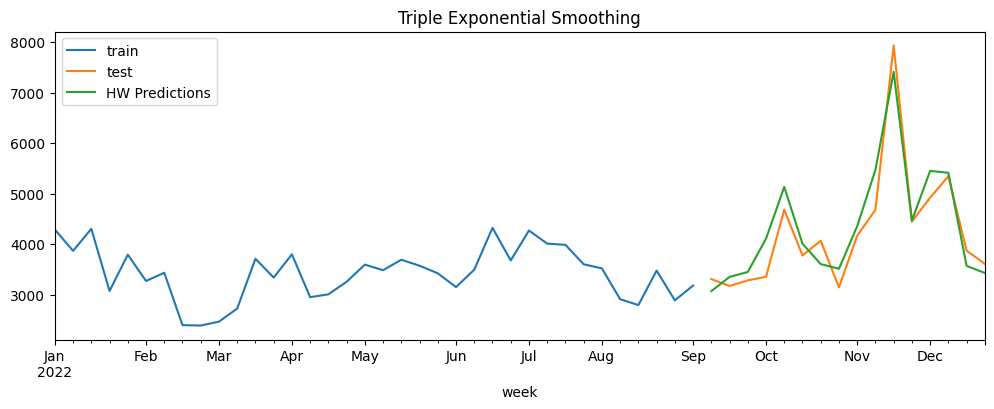

In [38]:
# Plot the time series, test and predictions
train.loc["2022"].plot(
    title = "Triple Exponential Smoothing",
    figsize=(12,4),
    legend = True,
    label = "train")
test.plot(
    legend = True,
    label = "test"
)
hw_predictions.plot(
    legend = True,
    label = "HW Predictions"
)
plt.show()

# Model Assessment

In [45]:
# Assess the 3 models for MAE, MAPE and RMSE
predictions = hw_predictions
mae_ses = mean_absolute_error(test, predictions)
mape_ses = mean_absolute_percentage_error(test, predictions)
rmse_ses = root_mean_squared_error(test, predictions)
print("Simple Exponential Smoothing")
print(f"MAE: {mae_ses:.1f}")
print(f"MAPE: {100 * mape_ses:.1f}%")
print(f"RMSE: {rmse_ses:.1f}")

Simple Exponential Smoothing
MAE: 341.1
MAPE: 8.3%
RMSE: 406.3


# Predict the Future

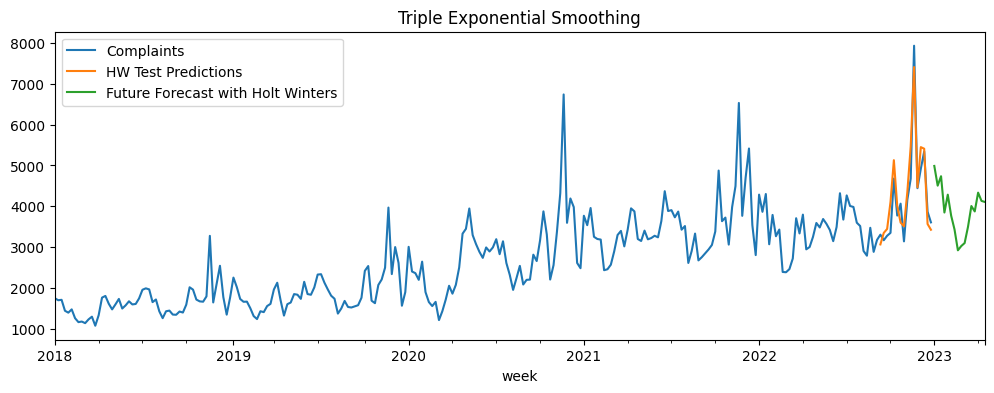

In [48]:
# Build the Holt-Winters model with the complete data
model_holt_complete = ExponentialSmoothing(
      df["y"],
      trend = "mul",
      seasonal = "mul",
      seasonal_periods = 52).fit()

# Forecast the future
forecast_future = model_holt_complete.forecast(periods)

# Plot the data, the test predictions, and the forecast future
df.y.plot(
    title = "Triple Exponential Smoothing",
    figsize=(12,4),
    legend = True,
    label = "Complaints")
hw_predictions.plot(
    legend = True,
    label = "HW Test Predictions"
)
forecast_future.plot(
    legend = True,
    label = "Future Forecast with Holt Winters"
)
plt.show()

# Daily Data

In [53]:
# Load the bitcoin price data
df_daily = pd.read_csv(
    "bitcoin_price.csv", index_col = "Date", parse_dates= True)['Close'].rename("y")
df_daily.head()

,y
Date,
2014-09-17,457.334015
2014-09-18,424.440002
2014-09-19,394.795990
2014-09-20,408.903992
2014-09-21,398.821014


In [58]:
# Set the frequency to daily
df_daily = df_daily.asfreq("D")
df_daily.head()

,y
Date,
2014-09-17,457.334015
2014-09-18,424.440002
2014-09-19,394.795990
2014-09-20,408.903992
2014-09-21,398.821014


In [59]:
# Split the data into training and test
test_periods = 30
train_daily = df_daily.iloc[:-test_periods]
test_daily = df_daily.iloc[-test_periods:]

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


MAE: 1806.7
MAPE: 4.3%
RMSE: 2606.6


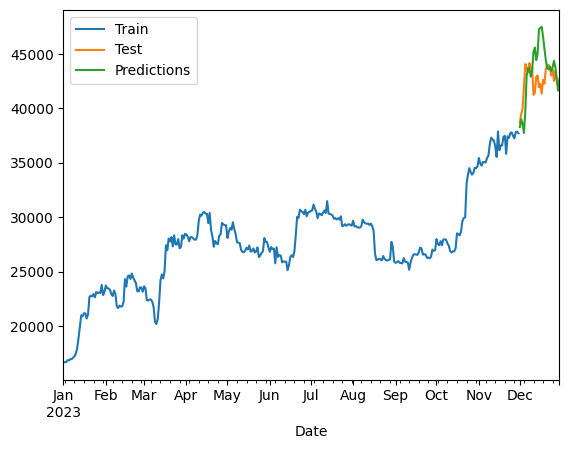

In [65]:
# Build the Holt Winters Model
model_daily = ExponentialSmoothing(
      train_daily,
      trend = "mul",
      seasonal = "mul",
      seasonal_periods = 365).fit()

# Predictions
predictions_daily = model_daily.forecast(test_periods)

# Model Assessment
mae_daily = mean_absolute_error(test_daily, predictions_daily)
mape_daily = mean_absolute_percentage_error(test_daily, predictions_daily)
rmse_daily = root_mean_squared_error(test_daily, predictions_daily)
print(f"MAE: {mae_daily:.1f}")
print(f"MAPE: {100 * mape_daily:.1f}%")
print(f"RMSE: {rmse_daily:.1f}")

# Plot the train and test and predictions
train_daily.loc["2023"].plot(
    legend = True,
    label = "Train"
)
test_daily.plot(
    legend = True,
    label = "Test"
)
predictions_daily.plot(
    legend = True,
    label = "Predictions"
)
plt.show()